# Exploratory Analysis

The goal of this notebook is to analyze patterns in the position-adjusted NFL player value scores created in `03_value_score_engineering.ipynb`.

The main input is `data/processed/player_value_scores_2016_2025.csv`. The core value metric is `value_score`, a season-position z-score of EPA per game. For quarterbacks, `value_epa_per_game` equals `qb_epa_per_game`; for running backs, wide receivers, and tight ends, it equals `scrimmage_epa_per_game`.

## Load Value Scores

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

def find_project_root(expected_file):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {expected_file} from working directory {Path.cwd()}"
    )

project_root = find_project_root("data/processed/player_value_scores_2016_2025.csv")
processed_dir = project_root / "data" / "processed"

value_scores_path = processed_dir / "player_value_scores_2016_2025.csv"
value_scored = pd.read_csv(value_scores_path)

print(value_scored.shape)
value_scored.head()


(4848, 79)


,season,player_id,player_name,player_display_name,position,team,completions,attempts,passing_yards,passing_tds,...,scrimmage_tds_per_game,interceptions_per_game,epa_only_score,qb_epa_per_game_z,value_score,value_epa_per_game,value_metric,scrimmage_epa_per_game_z,position_season_rank,position_season_percentile
0,2016,00-0019596,T.Brady,Tom Brady,QB,NE,291,432,3554,28,...,0.000,0.166667,11.719361,2.264787,2.264787,11.719361,position_adjusted_epa_per_game,NaN,1.0,1.00
1,2016,00-0020531,D.Brees,Drew Brees,QB,NO,471,673,5208,37,...,0.125,0.937500,6.604510,1.172466,1.172466,6.604510,position_adjusted_epa_per_game,NaN,7.0,0.88
2,2016,00-0021206,J.McCown,Josh McCown,QB,CLE,90,165,1100,6,...,0.000,1.200000,-5.810295,-1.478825,-1.478825,-5.810295,position_adjusted_epa_per_game,NaN,48.0,0.06
3,2016,00-0021429,C.Palmer,Carson Palmer,QB,ARI,364,597,4233,26,...,0.000,0.933333,1.750755,0.135903,0.135903,1.750755,position_adjusted_epa_per_game,NaN,22.0,0.58
4,2016,00-0022803,E.Manning,Eli Manning,QB,NYG,377,598,4027,26,...,0.000,1.000000,-1.263252,-0.507764,-0.507764,-1.263252,position_adjusted_epa_per_game,NaN,34.0,0.34


## Quick Data Checks

Confirm the positions, seasons, and key value-score columns are present before plotting.

In [2]:
required_cols = [
    "season", "player_id", "player_display_name", "position", "team",
    "games_played", "value_epa_per_game", "value_score",
    "position_season_rank", "position_season_percentile"
]

missing_cols = [col for col in required_cols if col not in value_scored.columns]
print("Missing columns:", missing_cols)

print("Seasons:", sorted(value_scored["season"].dropna().unique()))
print("Positions:", value_scored["position"].value_counts().to_dict())


Missing columns: []
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Positions: {'WR': 1990, 'RB': 1261, 'TE': 1040, 'QB': 557}


## Top Players By Season And Position

In [3]:
season_to_check = 2024

for pos in ["QB", "RB", "WR", "TE"]:
    print()
    print("Top", pos + "s", "in", season_to_check)
    display(
        value_scored[
            (value_scored["season"] == season_to_check) &
            (value_scored["position"] == pos)
        ][[
            "player_display_name", "team", "games_played",
            "value_epa_per_game", "value_score", "position_season_rank",
            "position_season_percentile"
        ]]
        .sort_values("value_score", ascending=False)
        .head(10)
    )



Top QBs in 2024


,player_display_name,team,games_played,value_epa_per_game,value_score,position_season_rank,position_season_percentile
458,Josh Allen,BUF,16,11.694598,2.341023,1.0,1.000000
456,Lamar Jackson,BAL,17,10.819503,2.157571,2.0,0.982759
448,Jared Goff,DET,17,9.731166,1.929417,3.0,0.965517
465,Tua Tagovailoa,MIA,11,7.845927,1.534202,4.0,0.948276
469,Joe Burrow,CIN,17,7.716457,1.507061,5.0,0.931034
457,Baker Mayfield,TB,17,7.187215,1.396113,6.0,0.913793
491,Jayden Daniels,WAS,17,7.021948,1.361467,7.0,0.896552
475,Brock Purdy,SF,15,6.467155,1.245162,8.0,0.879310
454,Patrick Mahomes,KC,16,5.965414,1.139979,9.0,0.862069
468,Jalen Hurts,PHI,15,5.410663,1.023683,10.0,0.844828



Top RBs in 2024


,player_display_name,team,games_played,value_epa_per_game,value_score,position_season_rank,position_season_percentile
4073,Saquon Barkley,PHI,16,3.091323,2.834717,1.0,1.000000
4331,Jahmyr Gibbs,DET,17,2.943068,2.716515,2.0,0.991453
4002,Derrick Henry,BAL,17,2.918026,2.696549,3.0,0.982906
4344,Bucky Irving,TB,17,2.085315,2.032642,4.0,0.974359
4026,Austin Ekeler,WAS,12,1.566792,1.619231,5.0,0.965812
4269,Bijan Robinson,ATL,17,1.504998,1.569964,6.0,0.957265
4210,James Cook,BUF,16,1.462196,1.535839,7.0,0.948718
4099,Ty Johnson,BUF,17,1.415872,1.498905,8.0,0.940171
4284,Chris Rodriguez Jr.,WAS,7,1.296949,1.404090,9.0,0.931624
4310,Sean Tucker,TB,17,1.032204,1.193012,10.0,0.923077



Top WRs in 2024


,player_display_name,team,games_played,value_epa_per_game,value_score,position_season_rank,position_season_percentile
4188,Amon-Ra St. Brown,DET,17,5.631994,3.255395,1.0,1.000000
4037,Chris Godwin Jr.,TB,7,5.292430,3.025940,2.0,0.995169
4330,Puka Nacua,LA,11,4.953729,2.797068,3.0,0.990338
4109,A.J. Brown,PHI,13,4.754705,2.662580,4.0,0.985507
4328,Rashee Rice,KC,4,4.705721,2.629480,5.0,0.980676
4145,Tee Higgins,CIN,12,4.700108,2.625687,6.0,0.975845
4181,Ja'Marr Chase,CIN,17,4.648951,2.591119,7.0,0.971014
4184,DeVonta Smith,PHI,13,4.332662,2.377391,8.0,0.966184
4393,Ladd McConkey,LAC,16,4.106715,2.224710,9.0,0.961353
3972,Adam Thielen,CAR,10,4.042908,2.181594,10.0,0.956522



Top TEs in 2024


,player_display_name,team,games_played,value_epa_per_game,value_score,position_season_rank,position_season_percentile
4012,George Kittle,SF,15,4.529662,4.028512,1.0,1.000000
4029,Jonnu Smith,MIA,17,3.415807,2.892112,2.0,0.990291
4064,Mark Andrews,BAL,17,3.149715,2.620634,3.0,0.980583
4015,Taysom Hill,NO,8,3.145811,2.616651,4.0,0.970874
4240,Trey McBride,ARI,16,3.104528,2.574532,5.0,0.961165
4315,Tucker Kraft,GB,17,2.383122,1.838524,6.0,0.951456
4180,Pat Freiermuth,PIT,17,2.111837,1.561748,7.0,0.941748
4070,Mike Gesicki,CIN,16,2.110473,1.560357,8.0,0.932039
4326,Sam LaPorta,DET,16,1.963960,1.410878,9.0,0.922330
4053,Dallas Goedert,PHI,10,1.936624,1.382988,10.0,0.912621


## Top Player-Seasons Overall

Because `value_score` is standardized within season-position groups, this table can compare unusually strong seasons across positions more fairly than raw EPA per game.

In [4]:
value_scored[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_per_game", "value_score", "position_season_rank"
]].sort_values("value_score", ascending=False).head(25)


,season,player_display_name,position,team,games_played,value_epa_per_game,value_score,position_season_rank
1006,2017,Rob Gronkowski,TE,NE,13,5.737153,5.577377,1.0
4712,2025,Puka Nacua,WR,LA,16,7.814466,5.293103,1.0
4012,2024,George Kittle,TE,SF,15,4.529662,4.028512,1.0
2862,2021,Cooper Kupp,WR,LA,17,6.558720,4.015558,1.0
3145,2022,Travis Kelce,TE,KC,17,3.913267,4.008751,1.0
2289,2020,Travis Kelce,TE,KC,15,5.014661,3.961691,1.0
3775,2023,CeeDee Lamb,WR,DAL,17,6.582844,3.937613,1.0
1368,2017,Alvin Kamara,RB,NO,16,4.277100,3.855051,1.0
3270,2022,Dallas Goedert,TE,PHI,12,3.765666,3.836433,2.0
4699,2025,Tucker Kraft,TE,GB,8,4.805345,3.671043,1.0


## Value Score Distribution By Position

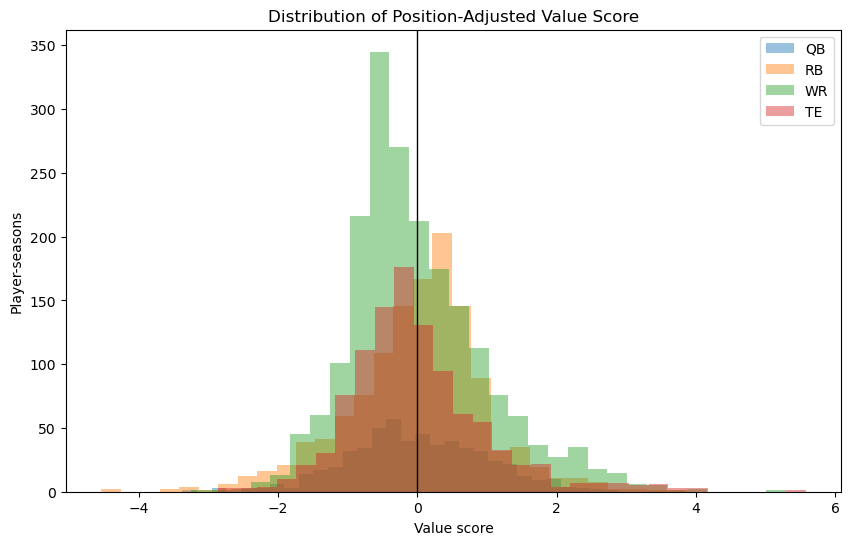

In [5]:
positions = ["QB", "RB", "WR", "TE"]

plt.figure(figsize=(10, 6))
for pos in positions:
    subset = value_scored.loc[value_scored["position"] == pos, "value_score"].dropna()
    plt.hist(subset, bins=30, alpha=0.45, label=pos)

plt.axvline(0, color="black", linewidth=1)
plt.title("Distribution of Position-Adjusted Value Score")
plt.xlabel("Value score")
plt.ylabel("Player-seasons")
plt.legend()
plt.show()


## Age And Experience Patterns

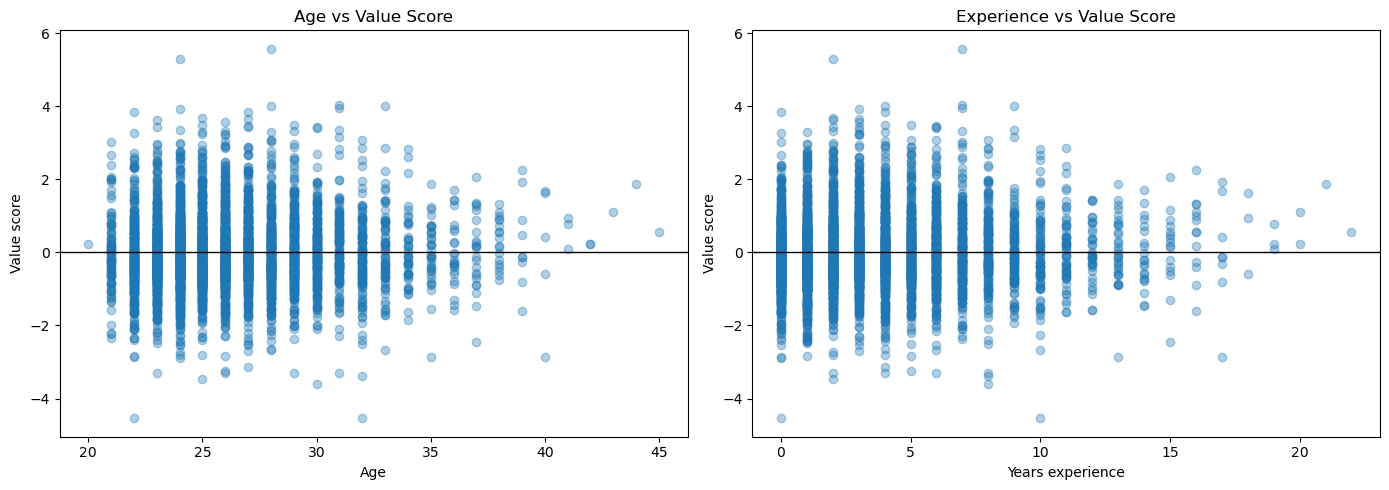

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = value_scored.dropna(subset=["age", "value_score"])
axes[0].scatter(plot_df["age"], plot_df["value_score"], alpha=0.35)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Age vs Value Score")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Value score")

plot_df = value_scored.dropna(subset=["years_exp", "value_score"])
axes[1].scatter(plot_df["years_exp"], plot_df["value_score"], alpha=0.35)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Experience vs Value Score")
axes[1].set_xlabel("Years experience")
axes[1].set_ylabel("Value score")

plt.tight_layout()
plt.show()


## Compare Value Score To Supporting Statistics

Supporting variables help interpret rankings and will be useful for predictive modeling, but they are not part of the main EPA-only value score.

In [7]:
supporting_cols = [
    "value_score", "value_epa_per_game", "yards_per_game", "tds_per_game",
    "scrimmage_yards_per_game", "scrimmage_touches_per_game",
    "yards_per_scrimmage_touch", "qb_yards_per_play", "qb_tds_per_game",
    "interceptions_per_game", "age", "years_exp", "draft_number"
]

available_cols = [col for col in supporting_cols if col in value_scored.columns]

corr = value_scored[available_cols].corr(numeric_only=True)["value_score"].sort_values(ascending=False)
corr


value_score                   1.000000
value_epa_per_game            0.781876
scrimmage_yards_per_game      0.414115
tds_per_game                  0.319717
yards_per_game                0.237785
yards_per_scrimmage_touch     0.201056
qb_tds_per_game               0.143074
scrimmage_touches_per_game    0.118080
qb_yards_per_play             0.100412
years_exp                     0.053908
age                           0.032936
interceptions_per_game       -0.033822
draft_number                 -0.116476
Name: value_score, dtype: float64

## Methodological Limitation

The value score is production-based. It does not fully capture blocking, route quality, offensive scheme, offensive line effects, defensive attention, or teammate effects. Tight ends are especially affected because blocking value is not represented well in the current data.